## Lecture 7: Distributed Dask in Practice

### ****Exercise 1:** Set Up a Strato Dask Cluster**

**Before you start — confirm you have:**
- **A Strato account and can SSH into your VM (https://hpc.aau.dk/strato/)**
- **A running VM (not shelved) with a floating IP assigned**

**If not, work through CLAAUDIA’s Strato guide first, then continue here.**

****Follow the step-by-step Dask cluster guide on Moodle:** `strato_dask_setup.md`**

Access via
```sh
ssh -i nsc ubuntu@10.92.y.x
```

****Done?** `client.run(...)` returns matching versions on all workers → move to MP2 M1**

Please see the document "l07_strato_dask_setup.ipynb" part 4.4. All workers do return the same version of 2026.3.0.

### ****Milestone 1:** Dask Mandelbrot on Strato cluster**

****Grid size:** use $N = 4096$ (or larger) — 1024 is too small; network overhead dominates and speedup is marginal. Also run a serial Numba baseline at the same resolution to compute speedup.**

#### **What to Benchmark**

##### ****Experiment 1:** Chunk size sweep**

**Fix all worker VMs connected; vary chunk size.**

- **Record wall time (median of 3 runs) per chunk size**

Please see the document "l07_strato_dask_setup.ipynb" in part 5. In that exercise I varied the number of chunks and workers. I used $N=4096$.

In [1]:
import pandas as pd
from IPython.display import display, Markdown

df = pd.read_csv("l07_part5.csv")
df["time"] = df["time"].map("{:>.3f}s".format)
display(Markdown(df[["workers", "chunks", "time"]].to_markdown(index=False)))

|   workers |   chunks | time   |
|----------:|---------:|:-------|
|         1 |        1 | 1.646s |
|         1 |        2 | 0.907s |
|         1 |        4 | 0.918s |
|         1 |        8 | 1.011s |
|         1 |       16 | 1.011s |
|         1 |       32 | 0.984s |
|         2 |        1 | 1.527s |
|         2 |        2 | 0.933s |
|         2 |        4 | 0.858s |
|         2 |        8 | 0.758s |
|         2 |       16 | 0.646s |
|         2 |       32 | 0.598s |
|         3 |        1 | 1.700s |
|         3 |        2 | 0.951s |
|         3 |        4 | 0.841s |
|         3 |        8 | 0.873s |
|         3 |       16 | 0.540s |
|         3 |       32 | 0.559s |

- **Note best chunk size**

Please see the document "l07_strato_dask_setup.ipynb" in part 5. In that exercise I varied the number of chunks and workers.

In [2]:
import pandas as pd

df = pd.read_csv("l07_part5.csv")

row_idx = df["time"].idxmin()
best_chunk_size = int(df.iloc[row_idx]["chunks"])
best_workers = int(df.iloc[row_idx]["workers"])

print(f"Best chunk size of {best_chunk_size} using {best_workers} workers nodes")

Best chunk size of 16 using 3 workers nodes


- **How does it compare to your L06-M2 result?**

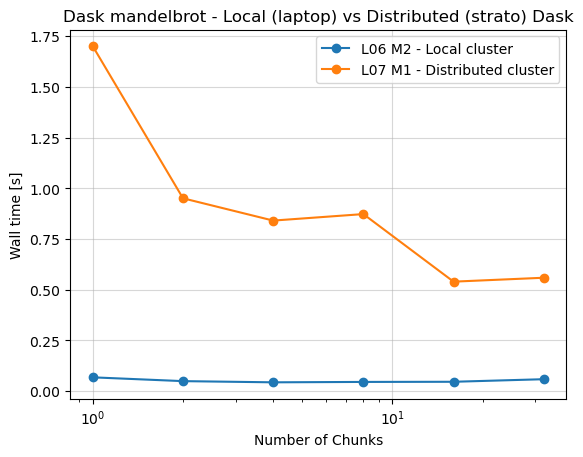

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Include result form both L06 milestone 1 and 2
l06_m2 = pd.read_csv("l06_milestone1.csv")
l07_m1 = pd.read_csv("l07_part5.csv")

# Using 3 worker nodes, in total 2*3 = 6 threads.
# Lecture 6 used 8 threads/workers in total.
l07_m1_subset = l07_m1.loc[l07_m1["workers"] == 3]

l06_m2_time = l06_m2["time"]
l06_m2_chunks = l06_m2["n_chunks"]

l07_m1_subset_time = l07_m1_subset["time"]
l07_m1_subset_chunks = l07_m1_subset["chunks"]

# plot
plt.plot(l06_m2_chunks, l06_m2_time, marker="o", label="L06 M2 - Local cluster")
plt.plot(l07_m1_subset_chunks, l07_m1_subset_time, marker="o", label="L07 M1 - Distributed cluster")
plt.xscale("log")
plt.xlabel("Number of Chunks")
plt.ylabel("Wall time [s]")
plt.grid(alpha=0.5)
plt.title("Dask mandelbrot - Local (laptop) vs Distributed (strato) Dask")
plt.legend()
plt.show()

Let's also plot the speedups.

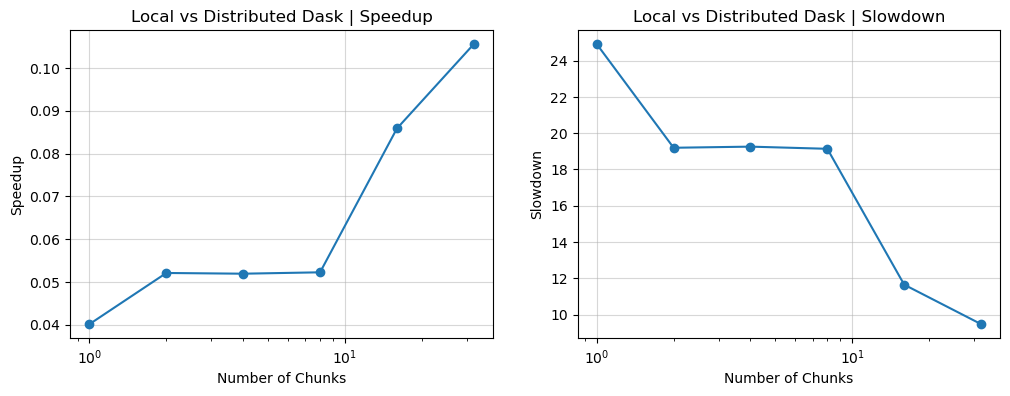

In [4]:
speedups = np.array(l06_m2_time) / np.array(l07_m1_subset_time)
slowdowns = 1 / speedups

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Speedup
axes[0].plot(l06_m2_chunks, speedups, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of Chunks")
axes[0].set_ylabel("Speedup")
axes[0].grid(alpha=0.5)
axes[0].set_title("Local vs Distributed Dask | Speedup")

# Slowdown
axes[1].plot(l06_m2_chunks, slowdowns, marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of Chunks")
axes[1].set_ylabel("Slowdown")
axes[1].grid(alpha=0.5)
axes[1].set_title("Local vs Distributed Dask | Slowdown")
plt.show()

Please note that Lecture 6 used a size of 1024 and 8 workers, while Lecture 7 used a size of 4096 with 6 workers. I would personally not compare them, but I have done as told so. To no surprise, the local cluster is WAY faster than the Strato cluster. We also see that, as the number of chunks grows, the Strato cluster becomes faster, which is to be expected.

##### ****Experiment 2:** Worker scaling**

**Fix best chunk size; vary number of active worker VMs.**

- **Start `dask-worker` on one VM; benchmark**

- **Add the next VM; benchmark again**

- **Repeat up to all VMs**

Please see the document "l07_strato_dask_setup.ipynb" in part 5. In that exercise I varied the number of chunks and workers.

- **Does wall time scale linearly with worker count?**

In [5]:
df = pd.read_csv("l07_part5.csv")
df_subset = df.loc[df["chunks"] == best_chunk_size]

df_subset["time"] = df_subset["time"].map("{:>.3f}s".format)

print(f"Best chunk size was {best_chunk_size}")
display(Markdown(df_subset[["workers", "time"]].to_markdown(index=False)))

Best chunk size was 16


|   workers | time   |
|----------:|:-------|
|         1 | 1.011s |
|         2 | 0.646s |
|         3 | 0.540s |

#### **Record in Performance Notebook**

- **Cluster configuration: number of worker VMs, vCPUs per VM, total workers**

Please see the document "l07_strato_dask_setup.ipynb" part 5 for more info.

- *Number of worker VMs*: 1-3
- *vCPU*: `AAU.CPU.b.2-4` (2 workers per VM)
- *Total workers*: 2-6


- **Grid size $N$ and `max_iter` used**

Please see the document "l07_strato_dask_setup.ipynb" part 5 for more info.

- *Grid size*: 4096
- *`max_iter`*: 100

- **Best chunk size from sweep and corresponding wall time**

Please see the document "l07_strato_dask_setup.ipynb" part 5 for more info.

- *Best chunk size:* 16
- *Best chunk size wall time:* 0.540s

- **Worker scaling: wall time vs. worker count (table or plot)**

Please see the table above in experiment number 2.

- **Speedup vs. serial Numba at the same resolution**

Please see the document "l07_strato_dask_setup.ipynb" in part 5 for more info. In that, I compared the speedup vs Numba serial. Here, I only plot the results.

In [6]:
# From exercise 1

from IPython.display import Markdown, display
import pandas as pd

df = pd.read_csv("l07_part5.csv")

# Compute speedups
t0 = 0.71728592099862 # serial numba
df["speedup"] = t0 / df["time"]

# Display as table
df["time"] = df["time"].map("{:>.3f}s".format)
df["speedup"] = df["speedup"].map("{:>.2f}x".format)
display(Markdown(df[["workers", "chunks", "time", "speedup"]].to_markdown(index=False)))

|   workers |   chunks | time   | speedup   |
|----------:|---------:|:-------|:----------|
|         1 |        1 | 1.646s | 0.44x     |
|         1 |        2 | 0.907s | 0.79x     |
|         1 |        4 | 0.918s | 0.78x     |
|         1 |        8 | 1.011s | 0.71x     |
|         1 |       16 | 1.011s | 0.71x     |
|         1 |       32 | 0.984s | 0.73x     |
|         2 |        1 | 1.527s | 0.47x     |
|         2 |        2 | 0.933s | 0.77x     |
|         2 |        4 | 0.858s | 0.84x     |
|         2 |        8 | 0.758s | 0.95x     |
|         2 |       16 | 0.646s | 1.11x     |
|         2 |       32 | 0.598s | 1.20x     |
|         3 |        1 | 1.700s | 0.42x     |
|         3 |        2 | 0.951s | 0.75x     |
|         3 |        4 | 0.841s | 0.85x     |
|         3 |        8 | 0.873s | 0.82x     |
|         3 |       16 | 0.540s | 1.33x     |
|         3 |       32 | 0.559s | 1.28x     |

****Also add a Numba serial entry to the performance tracker** at the same resolution as your clusterruns — this enables a meaningful speedup comparison across the class.**

In [7]:
# From lecture 3

# from slide 37. Approach B
from numba import njit
import numpy as np


@njit                       # <-- entire function compiled !
def mandelbrot_naive_numba(xmin, xmax, ymin, ymax, width, height, max_iter=100):
    """Fully JIT - compiled Mandelbrot --- structure identical to naive."""
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    result = np.zeros((height, width), dtype=np.int32)

    for i in range(height):             # compiled loop
        for j in range(width):          # compiled loop
            c = x[j] + 1j * y[i]
            z = 0j                      # complex literal: type inference works!
            n = 0
            while n < max_iter and (z.real*z.real + z.imag*z.imag) <= 4.0:
                z = z*z + c
                n += 1
            result[i, j] = n
    return result

In [8]:
# From lecture 5

from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [9]:
from multiprocessing import Pool
# From lecture 5

# From slide 27

# Extend your L04 mandelbrot parallel to (include n chunks):
def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4, n_chunks=None):
    if n_chunks is None:
        n_chunks = n_workers
    chunk_size = max(1, N // n_chunks)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    tiny = [(0, 8, 8, x_min, x_max, y_min, y_max, max_iter)]
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

In [10]:
# From lecture 6

# From slide 34

from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics
# mandelbrot_chunk: your @njit(cache=True) function from L04/L05
def mandelbrot_dask(N, x_min, x_max, y_min, y_max,
                    max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(
            row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

In [11]:
import pandas as pd
import time
# Copied mostly form lecture 6, my own benchmark function

def benchmark(name: str, func: callable):
    # skip benchmarking if needed
    if name == "Dask cluster":
        df = pd.read_csv("l07_part5.csv")
        time_res = df[(df["workers"] == 3) & (df["chunks"] == 16)]["time"].iloc[0]
        return time_res
    
    # Dask local cluster
    if func is mandelbrot_dask:
        cluster = LocalCluster(n_workers=8, threads_per_worker=1)
        client = Client(cluster)

    func()  # warm up

    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = func()
        times.append(time.perf_counter() - t0)
    
    if func is mandelbrot_dask:
        client.close()
        cluster.close()

    return statistics.median(times)

In [12]:
from mandelbrot import compute_mandelbrot
from mandelbrot import compute_mandelbrot_numpy

def compute_ms1():
    # Same names as the ones one moodle
    impl: dict[str, callable] = {
        "Naive Python": lambda: compute_mandelbrot(x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, width=4096, height=4096, max_iter=100),
        "Numpy vectorized": lambda: compute_mandelbrot_numpy(x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, width=4096, height=4096, max_iter=100),
        "Numba JIT": lambda: mandelbrot_naive_numba(xmin=-2, xmax=1, ymin=-1.5, ymax=1.5, width=4096, height=4096, max_iter=100),
        "Multiprocessing": lambda: mandelbrot_parallel(N=4096, x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, max_iter=100, n_workers=8, n_chunks=16),
        "Dask local": lambda: mandelbrot_dask(N=4096, x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, max_iter=100, n_chunks=16),
        "Dask cluster": None, # Reuse results in csv file
    }

    names = []
    times = []
    speedups = []

    for name, func in impl.items():
        time = benchmark(name, func)
        
        times.append(time)
        names.append(name)
        t0 = times[0]
        speedups.append(t0 / time)
    
    return names, times, speedups

In [13]:
from pathlib import Path

ms1_file = Path("l07_ms1.csv")
if not ms1_file.exists():
    impl, times, speedups = compute_ms1()
    df = pd.DataFrame({
        "implementation": impl,
        "time": times,
        "speedup": speedups
    })
    df.to_csv(ms1_file, index_label=False)

****Done?** Record results in performance notebook (MP2) → commit**

In [14]:
from IPython.display import Markdown, display

df_display = pd.read_csv(ms1_file)
df_display["implementation"] = df_display["implementation"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)

display(Markdown(df_display.to_markdown(index=False)))

| implementation   | time    | speedup   |
|:-----------------|:--------|:----------|
| Naive Python     | 67.556s | 1.00x     |
| Numpy vectorized | 11.321s | 5.97x     |
| Numba JIT        | 0.751s  | 89.93x    |
| Multiprocessing  | 0.359s  | 188.17x   |
| Dask local       | 0.738s  | 91.57x    |
| Dask cluster     | 0.540s  | 125.13x   |

Using 4096x4096 with `max_iter=100` and 8 CPU cores. It is notable that Python's multiprocessing is faster than Dask local cluster. I suspect that this is due to Dask introducing scheduler overhead with its graph-like structure for example.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 9568e8504ad27dac261fa798337fc443239bcbce (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Apr 1 11:45:21 2026 +0000

    l07: milestone 1 done
```

### ****Exercise 2 (optional):** Explore the Dask Dashboard**

**Run your chunk sweep again and observe the Dask dashboard task stream at two extremes:**
- ****Very small chunk size** — many short tasks**
- ****Very large chunk size** — few long tasks**

**For each, look at:**

- **Worker utilisation — are all workers busy throughout, or do some sit idle?**

- **Straggler tasks — do a few slow chunks delay the whole computation?**

- **Task stream colour pattern — uniform or uneven?**

I have adapted the code in `mandelbort_dask.py` to sweep from chunks 1 to 512.

In [15]:
!cat l07_ex2_mandelbrot_dask.py | tail --lines 30

n_chunks_arr = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
times_res = []
lifs = []
vs1x = []
speedups = []

for n_chunks in n_chunks_arr:
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        result = mandelbrot_dask(
            N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
        times.append(time.perf_counter() - t0)

    T_p = statistics.median(times)
    times_res.append(T_p)
    T_1 = times_res[0]
    vs1x.append(T_p / T_1)
    speedups.append(T_1 / T_p)
    lifs.append(8 * T_p / T_1 - 1)

client.close()

print("-"*10)
print(f"Number of chunks: {n_chunks_arr}")
print(f"Times: {times_res}")
#print(f"Lifs: {lifs}")
#print(f"vs 1x {vs1x}")
#print(f"Speedups {speedups}")
print("-"*10)


I have recorded a video of the dashboard saved as "L07_ex2.mp4" (t is too large for GitHub).

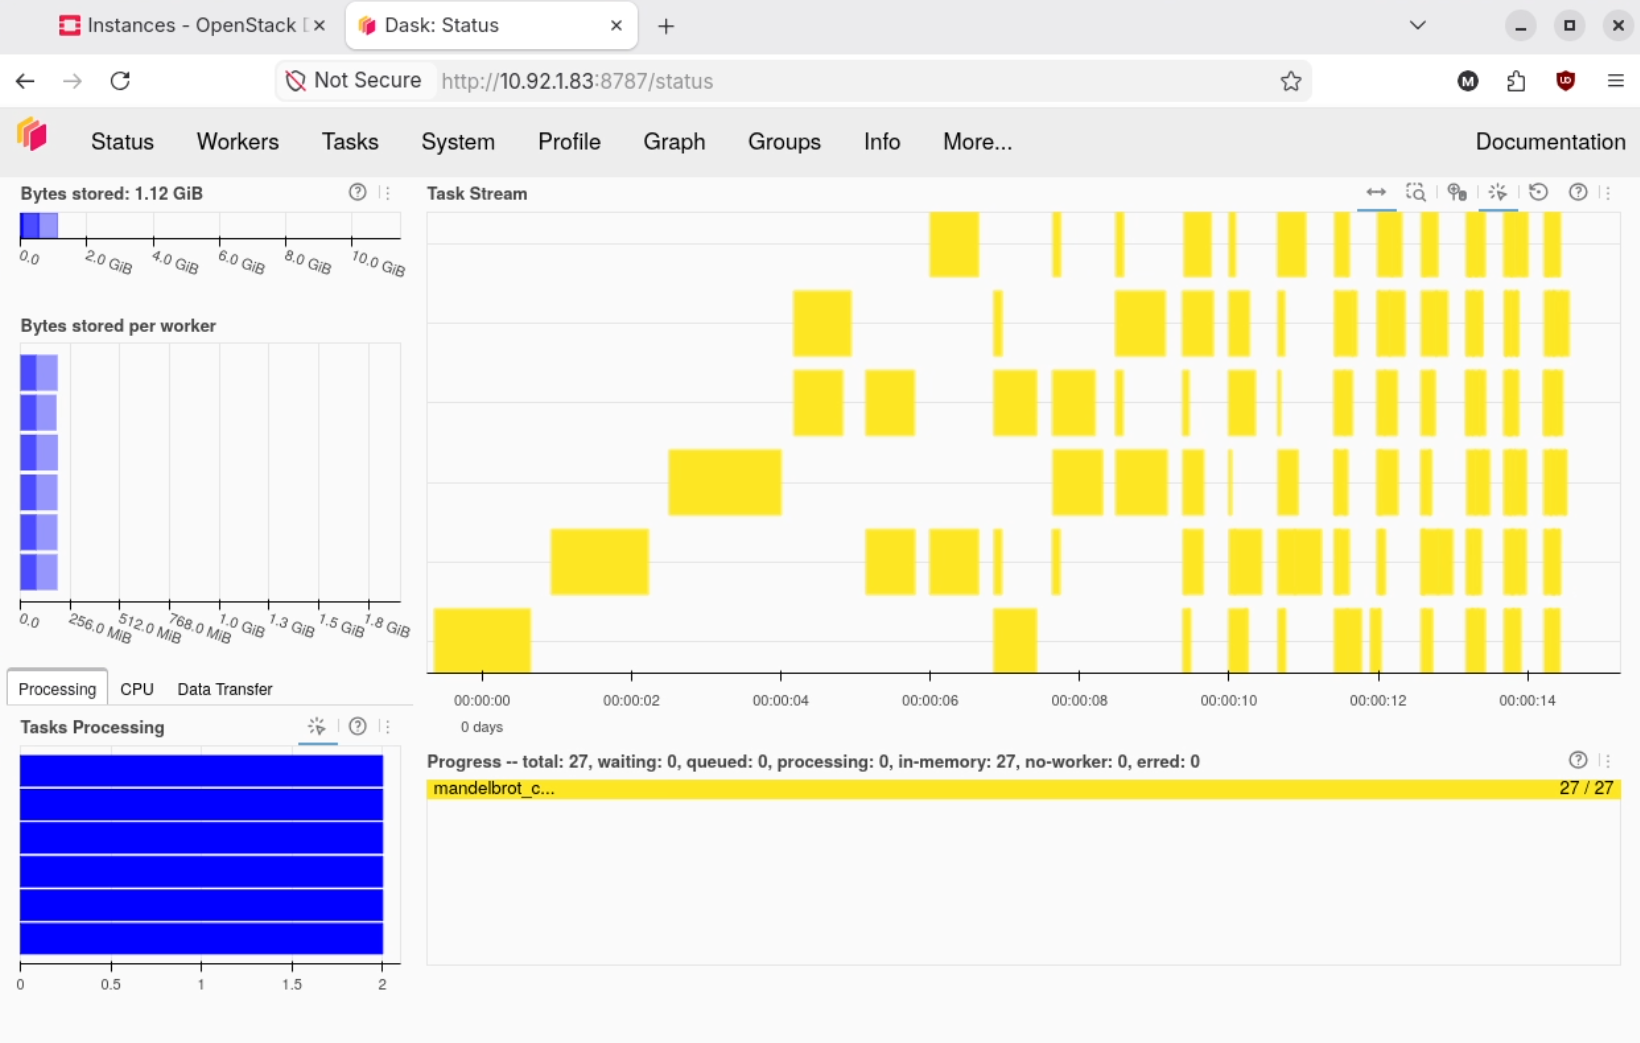

****Done?** Discuss your observations with a neighbour → move to Exercise 3**

*For large chunks:* From the dashboard, it seems that there are some stranglers between each chunk sweep.

*For smaller chunks:* The stranglers are somewhat mitigated.

Overall, work utilisation remains high, and the colours are the same.

### ****Exercise 3 (optional):** Load Balance in a Compute-Intensive Region**

**The default Mandelbrot view is mostly exterior — early exit keeps most chunks fast. Try zooming into a region where early exit rarely triggers.**

**A compute-intensive example (near the boundary of the main cardioid):**

- **`x_min, x_max = -0.75, -0.74`**
- **`y_min, y_max = 0.099, 0.109`**
- **Increase `max_iter` to 1000 or more**

In [16]:
!cat l07_ex3_mandelbrot_dask.py | tail --lines 28

X_MIN, X_MAX = -0.75, -0.74
Y_MIN, Y_MAX = 0.099, 0.109
N, max_iter = 4096, 1000
client = Client("tcp://10.92.1.83:8786") # Use remote cluster at strato
client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX,  # warm up all workers
                                    Y_MIN, Y_MAX, 10))

n_chunks_arr = [1, 2, 4, 8, 16, 32]
times_res = []

for n_chunks in n_chunks_arr:
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        result = mandelbrot_dask(
            N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
        times.append(time.perf_counter() - t0)

    T_p = statistics.median(times)
    times_res.append(T_p)
    T_1 = times_res[0]

client.close()

print("-"*10)
print(f"Number of chunks: {n_chunks_arr}")
print(f"Times: {times_res}")
print("-"*10)


The results are saved to "l07_ex3.csv".

**Run the chunk sweep and compare with your M1 results:**

In [17]:
import pandas as pd

ms1_df_full = pd.read_csv("l07_part5.csv")
ms1_df = ms1_df_full[ms1_df_full["workers"] == 3]
ex3_df = pd.read_csv("l07_ex3.csv") # Only measured for 3 workers

- **Does the optimal chunk size change?**

In [18]:
def optimal_chunk_size(df: pd.DataFrame) -> int:
    row_idx = df["time"].idxmin()
    optimal_chunk_size = int(df.loc[row_idx, "chunks"])
    return optimal_chunk_size

ms1_optimal_chunk_size = optimal_chunk_size(ms1_df)
ex3_optimal_chunk_size = optimal_chunk_size(ex3_df)

print(f"MS1: {ms1_optimal_chunk_size}")
print(f"EX3: {ex3_optimal_chunk_size}")

MS1: 16
EX3: 32


Yes, the optimal chunk size does change.

- **Is load balance better or worse? Check the dashboard task stream.**

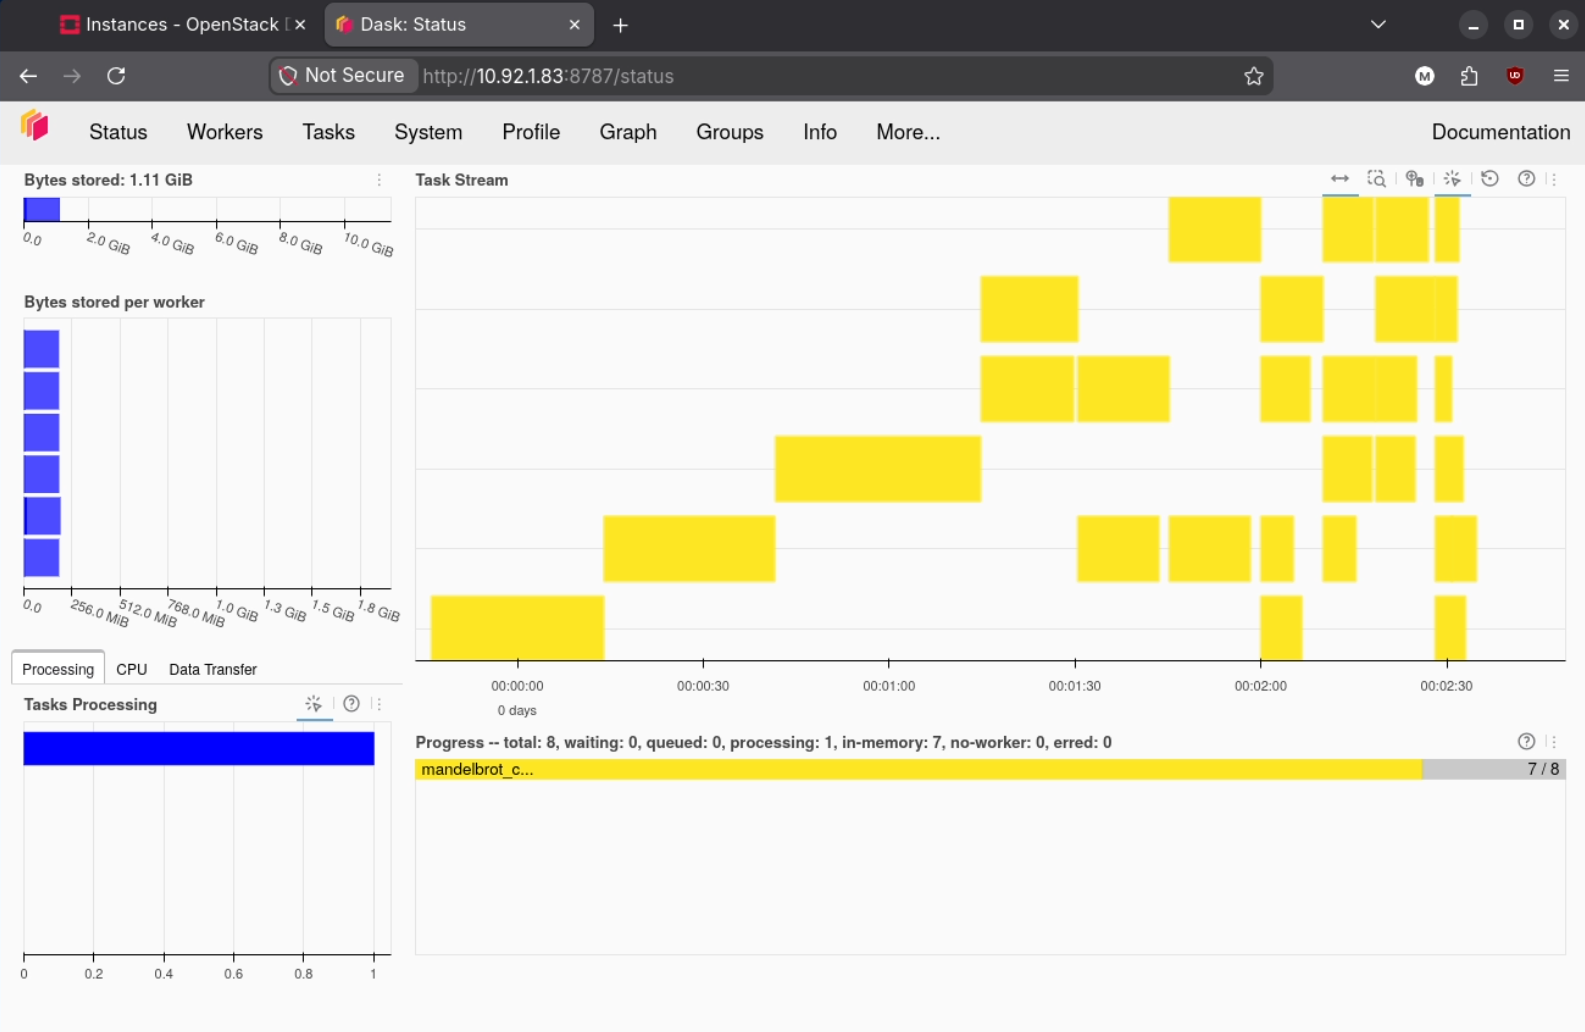

It's the same pattern.

- **How does wall time compare to the default view at the same N?**

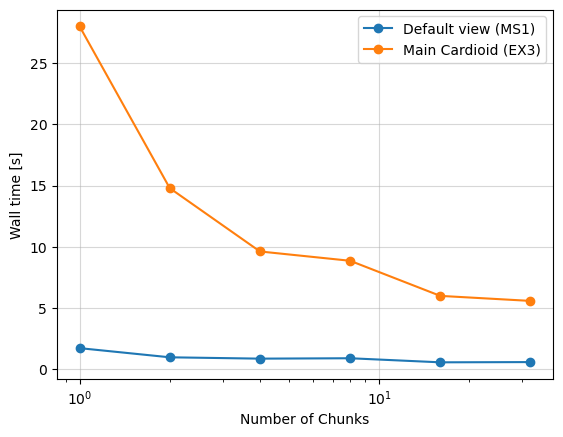

In [19]:
import matplotlib.pyplot as plt

ms1_wall_times = ms1_df["time"]
ex3_wall_times = ex3_df["time"]
chunks = ex3_df["chunks"]

plt.plot(chunks, ms1_wall_times, marker="o", label="Default view (MS1)")
plt.plot(chunks, ex3_wall_times, marker="o", label="Main Cardioid (EX3)")
plt.xscale("log")
plt.xlabel("Number of Chunks")
plt.ylabel("Wall time [s]")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

By no surprise, it takes longer to compute the Cardioid region than the default one.

****Done?** Discuss with a neighbour**

Noted! They saw the same trend.